# Microdosimetric Spectra from Monte Carlo Simulation

This notebook demonstrates the complete microdosimetric spectra pipeline for
the 4H-SiC microdosimeter, following **ICRU Report 36** conventions:

1. **Load MC events** from Phase 22 synthetic dataset (2000 events)
2. **Process through CCE(LET)** lookup to obtain collected energies
3. **Compute lineal energy** y = epsilon / l_bar for the sensitive volume
4. **Build f(y) and d(y)** distributions on log-spaced bins
5. **Apply tissue-equivalence** correction via kappa = S_water / S_SiC
6. **Plot y*d(y) and y*f(y)** spectra in publication-quality format

The lineal energy y is the energy imparted per event divided by the mean chord
length of the sensitive volume. The frequency distribution f(y) gives the
probability density per unit y, while the dose distribution d(y) = y * f(y) / y_F
weights events by their contribution to absorbed dose.

**Key quantities:**
- y_F (frequency-mean lineal energy): characterizes the average event
- y_D (dose-mean lineal energy): characterizes the dose-average event
- Jensen's inequality guarantees y_D >= y_F for any valid spectrum

**Reference:** ICRU Report 36, *Microdosimetry* (1983)

In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from src.microdosimetry import (
    mean_chord_length,
    lineal_energy_spectrum,
    compute_kappa_table,
    tissue_equivalence_correction,
    plot_yd_spectrum,
    plot_yf_spectrum,
)
from src.mc_coupling import load_mc_events_csv, process_mc_ensemble
from src.single_particle import load_cce_let_table

# Publication-quality plot defaults
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

print("Imports complete.")

Searching DEVSIM_MATH_LIBS="libopenblas.dylib:liblapack.dylib:libblas.dylib"
Loading "libopenblas.dylib": MISSING DLL
Loading "liblapack.dylib": ALL BLAS/LAPACK LOADED
Skipping libblas.dylib
loading UMFPACK 5.1 as direct solver
Imports complete.


## 1. Load Monte Carlo Data

The energy deposition data comes from Phase 22's synthetic Monte Carlo dataset
(2000 events mimicking a mixed proton + heavy-ion field). We load the step-level
CSV, aggregate per event, and apply the CCE(LET) lookup table to obtain
collected energies in the sensitive volume.

**Pipeline:** CSV -> load_mc_events_csv -> process_mc_ensemble -> collected energies

In [2]:
# Load synthetic MC events (step-level CSV from Phase 22)
events_df = load_mc_events_csv('data/synthetic_mc_events.csv')
print(f"Loaded events DataFrame: {events_df.shape[0]} steps, "
      f"{events_df['event_id'].nunique()} unique events")

# Load CCE(LET) lookup table (from Phase 21 TCAD)
cce_interp, cce_metadata = load_cce_let_table('data/cce_let_table_100um.json')
print(f"CCE table: {len(cce_metadata['LET_keV_um'])} points, "
      f"LET range {min(cce_metadata['LET_keV_um']):.2f} -- "
      f"{max(cce_metadata['LET_keV_um']):.1f} keV/um")

# Process ensemble: aggregate per-event, compute LET, apply CCE
result = process_mc_ensemble(events_df, cce_interp, sv_thickness_um=10.0)
print(f"\nProcessed {result['n_events']} events through CCE(LET) lookup.")

Loaded events DataFrame: 11116 steps, 2000 unique events
CCE table: 20 points, LET range 0.50 -- 500.0 keV/um

Processed 2000 events through CCE(LET) lookup.


In [3]:
# Summary statistics
print("=" * 60)
print("  MC Ensemble Summary Statistics")
print("=" * 60)
print(f"  Total events:          {result['n_events']}")
print(f"  Energy range (keV):    {result['event_energies_keV'].min():.1f} -- "
      f"{result['event_energies_keV'].max():.1f}")
print(f"  Mean energy (keV):     {result['event_energies_keV'].mean():.1f}")
print(f"  LET range (keV/um):    {result['event_LET_keV_um'].min():.2f} -- "
      f"{result['event_LET_keV_um'].max():.1f}")
print(f"  Mean LET (keV/um):     {result['event_LET_keV_um'].mean():.2f}")
print(f"  CCE range:             {result['event_CCE'].min():.4f} -- "
      f"{result['event_CCE'].max():.4f}")
print(f"  Mean CCE:              {result['event_CCE'].mean():.4f}")
print(f"  Collected E range:     {result['event_collected_keV'].min():.1f} -- "
      f"{result['event_collected_keV'].max():.1f} keV")
print("=" * 60)

  MC Ensemble Summary Statistics
  Total events:          2000
  Energy range (keV):    5.0 -- 2277.2
  Mean energy (keV):     344.6
  LET range (keV/um):    0.50 -- 227.7
  Mean LET (keV/um):     34.46
  CCE range:             1.0000 -- 1.0000
  Mean CCE:              1.0000
  Collected E range:     5.0 -- 2277.2 keV


## 2. Lineal Energy Computation

The lineal energy y is defined as:

$$y = \frac{\varepsilon}{\bar{\ell}}$$

where epsilon is the energy imparted in a single event and l_bar is the mean
chord length of the sensitive volume. For a rectangular parallelepiped
(100 x 100 x 10 um), the mean chord length is computed from **Cauchy's theorem**:

$$\bar{\ell} = \frac{4V}{S}$$

valid for convex bodies under isotropic irradiation, where V is the volume
and S is the surface area.

In [4]:
# Compute mean chord length for 100 x 100 x 10 um SV
l_bar = mean_chord_length(10.0, sv_width_um=100.0, sv_depth_um=100.0)
print(f"Sensitive volume:  100 x 100 x 10 um")
print(f"Mean chord length: l_bar = {l_bar:.3f} um")
print(f"")
print("(For comparison, slab approximation l_bar = 2*t = {:.1f} um)".format(2.0 * 10.0))
print(f"The 3D Cauchy formula gives a shorter chord length because")
print(f"the finite lateral extent reduces the average path length.")

Sensitive volume:  100 x 100 x 10 um
Mean chord length: l_bar = 16.667 um

(For comparison, slab approximation l_bar = 2*t = 20.0 um)
The 3D Cauchy formula gives a shorter chord length because
the finite lateral extent reduces the average path length.


In [5]:
# Compute lineal energy spectrum from collected energies
spec_sic = lineal_energy_spectrum(
    result['event_collected_keV'],
    l_bar_um=l_bar,
    y_min=0.01,
    y_max=1e4,
    bins_per_decade=50,
)

print("Lineal Energy Spectrum (SiC raw)")
print("=" * 50)
print(f"  Events:               {spec_sic['n_events']}")
print(f"  y_F (freq. mean):     {spec_sic['y_F']:.3f} keV/um")
print(f"  y_D (dose mean):      {spec_sic['y_D']:.3f} keV/um")
print(f"  y_D / y_F ratio:      {spec_sic['y_D'] / spec_sic['y_F']:.2f}")
print(f"  y_D >= y_F (Jensen):  {spec_sic['y_D'] >= spec_sic['y_F']}")
print(f"")

# Validate f(y) normalization
integral_fy = np.sum(spec_sic['f_y'] * spec_sic['bin_widths'])
print(f"  Integral f(y)*dy:     {integral_fy:.4f} (should be ~1.0)")

Lineal Energy Spectrum (SiC raw)
  Events:               2000
  y_F (freq. mean):     20.666 keV/um
  y_D (dose mean):      63.796 keV/um
  y_D / y_F ratio:      3.09
  y_D >= y_F (Jensen):  True

  Integral f(y)*dy:     1.0000 (should be ~1.0)


## 3. Figure 1: Dose-Weighted Lineal Energy Spectrum (SiC)

The standard microdosimetric representation plots **y*d(y) vs log(y)**.
In this representation, the area under the curve between any two y-values
is proportional to the dose fraction delivered by events in that lineal
energy range.

The vertical lines mark y_F (frequency-mean, dashed) and y_D (dose-mean, solid).

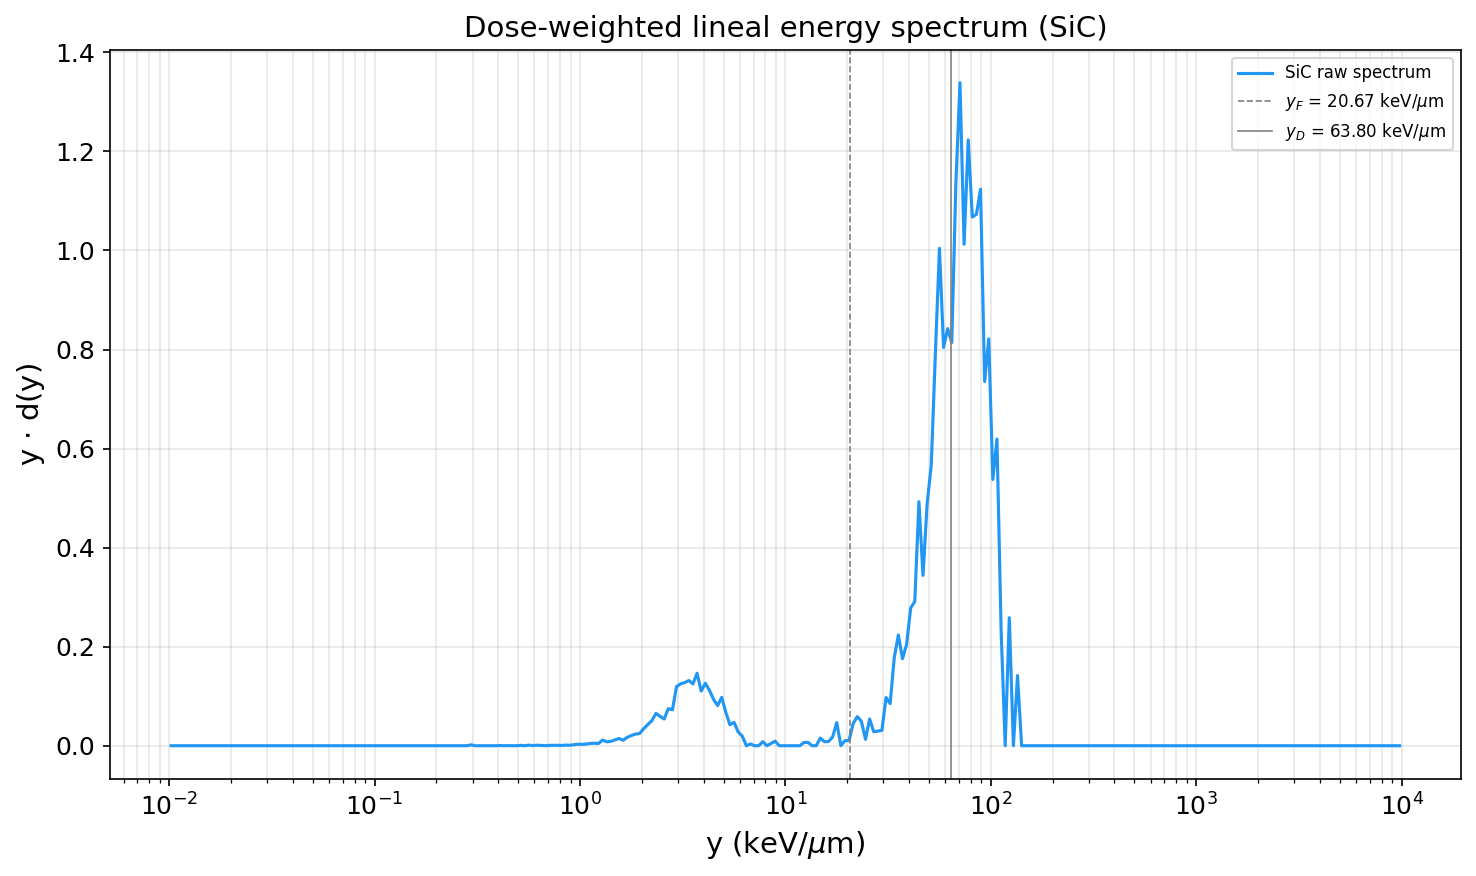

y_F = 20.666 keV/um
y_D = 63.796 keV/um


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_yd_spectrum(
    spec_sic['bin_centers'],
    spec_sic['d_y'],
    y_F=spec_sic['y_F'],
    y_D=spec_sic['y_D'],
    ax=ax,
    label='SiC raw spectrum',
    color='#2196F3',
)

ax.set_title('Dose-weighted lineal energy spectrum (SiC)')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"y_F = {spec_sic['y_F']:.3f} keV/um")
print(f"y_D = {spec_sic['y_D']:.3f} keV/um")

## 4. Figure 2: Frequency-Weighted Lineal Energy Spectrum (SiC)

The frequency-weighted representation **y*f(y) vs log(y)** shows the probability
density of events at each lineal energy. Unlike d(y), this weighting treats
all events equally regardless of their energy deposition.

Low-y events (e.g., proton-like) dominate the frequency spectrum, while the
dose spectrum emphasizes high-y events (heavy ions) that deposit more energy.

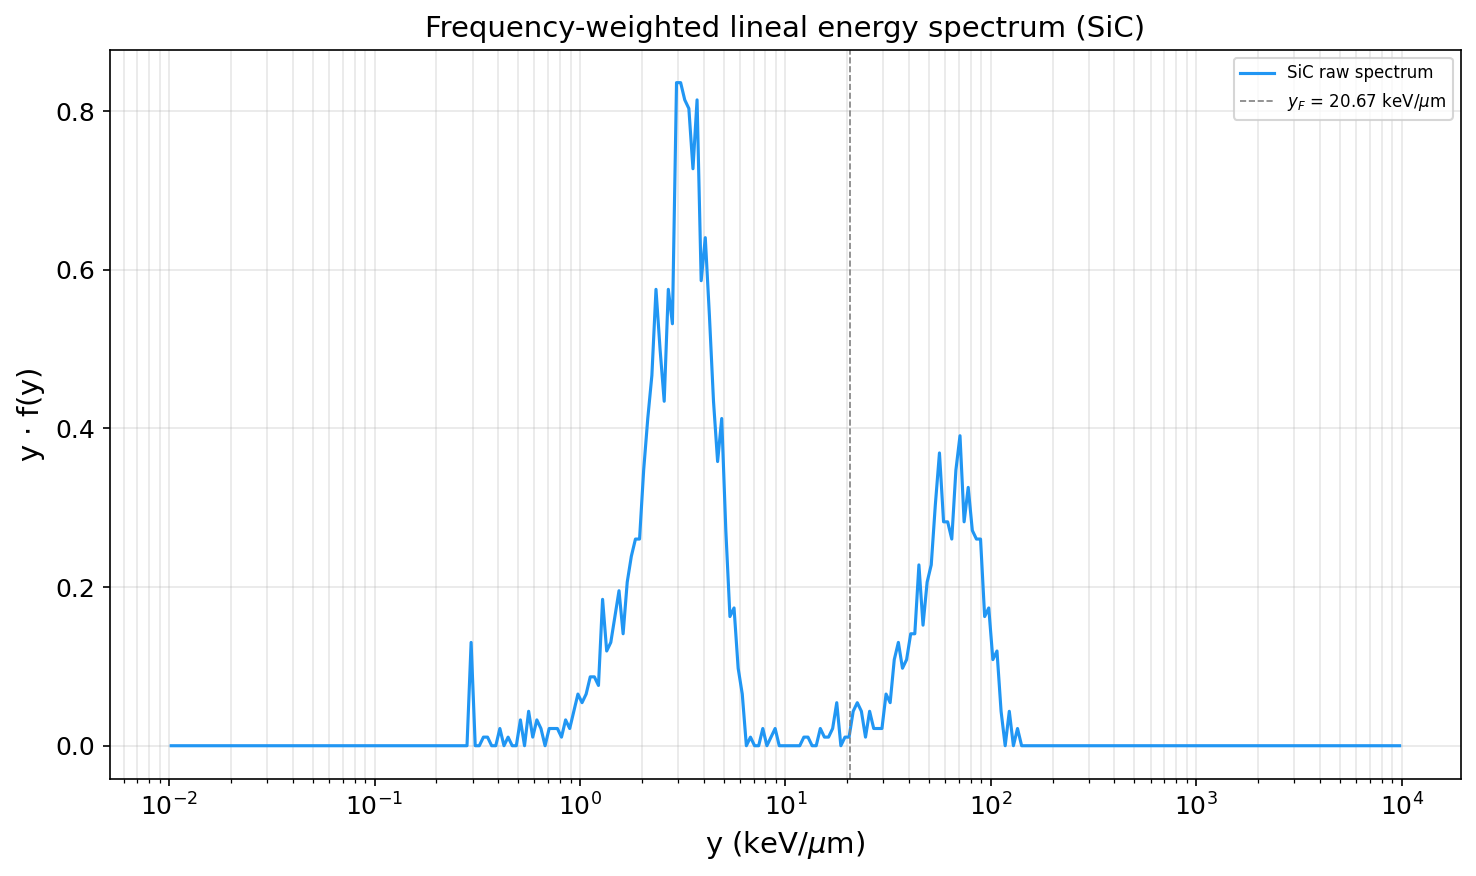

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_yf_spectrum(
    spec_sic['bin_centers'],
    spec_sic['f_y'],
    y_F=spec_sic['y_F'],
    ax=ax,
    label='SiC raw spectrum',
    color='#2196F3',
)

ax.set_title('Frequency-weighted lineal energy spectrum (SiC)')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 5. Tissue-Equivalence Correction

Silicon carbide is not tissue-equivalent: its stopping power differs from
water (the standard tissue surrogate). The tissue-equivalence correction
factor kappa converts SiC detector response to tissue-equivalent values:

$$\kappa(E) = \frac{S_{\text{water}}(E)}{S_{\text{SiC}}(E)}$$

where S is the mass stopping power at proton energy E. Since S_SiC > S_water
(higher Z material), kappa < 1, meaning tissue-equivalent lineal energies
are **lower** than SiC-raw values.

The stopping power data comes from:
- **Water:** PSTAR database (NIST)
- **SiC:** Bethe-Bloch scaling from SRIM data

In [8]:
# Compute energy-dependent kappa table from stopping power CSVs
kappa_table = compute_kappa_table(
    water_csv_path='data/stopping_power_water.csv',
    sic_csv_path='data/stopping_power_sic.csv',
)

print("Kappa Table (S_water / S_SiC)")
print("=" * 50)
print(f"  Energy points:   {len(kappa_table['energy_MeV'])}")
print(f"  Energy range:    {kappa_table['energy_MeV'].min():.2f} -- "
      f"{kappa_table['energy_MeV'].max():.0f} MeV")
print(f"  Kappa range:     {kappa_table['kappa'].min():.3f} -- "
      f"{kappa_table['kappa'].max():.3f}")
print(f"  Mean kappa:      {kappa_table['kappa'].mean():.3f}")
print(f"")
print("  Sample values:")
for i in range(0, len(kappa_table['energy_MeV']), 6):
    print(f"    E = {kappa_table['energy_MeV'][i]:8.2f} MeV  ->  "
          f"kappa = {kappa_table['kappa'][i]:.4f}")

Kappa Table (S_water / S_SiC)
  Energy points:   37
  Energy range:    0.10 -- 1000 MeV
  Kappa range:     0.575 -- 0.587
  Mean kappa:      0.580

  Sample values:
    E =     0.10 MeV  ->  kappa = 0.5867
    E =     0.50 MeV  ->  kappa = 0.5847
    E =     2.50 MeV  ->  kappa = 0.5797
    E =    10.00 MeV  ->  kappa = 0.5781
    E =    50.00 MeV  ->  kappa = 0.5784
    E =   250.00 MeV  ->  kappa = 0.5778
    E =  1000.00 MeV  ->  kappa = 0.5752


In [9]:
# Apply tissue-equivalence correction to lineal energy values
y_tissue = tissue_equivalence_correction(
    spec_sic['y_values'],
    result['event_energies_keV'],
    kappa_table=kappa_table,
)

print(f"Tissue-equivalence correction applied to {len(y_tissue)} events.")
print(f"  SiC y range:        {spec_sic['y_values'].min():.3f} -- "
      f"{spec_sic['y_values'].max():.1f} keV/um")
print(f"  Tissue y range:     {y_tissue.min():.3f} -- "
      f"{y_tissue.max():.1f} keV/um")
print(f"  Mean shift factor:  {np.mean(y_tissue / spec_sic['y_values']):.3f}")

Tissue-equivalence correction applied to 2000 events.
  SiC y range:        0.300 -- 136.6 keV/um
  Tissue y range:     0.176 -- 79.2 keV/um
  Mean shift factor:  0.585


In [10]:
# Recompute lineal energy spectrum with tissue-equivalent values
# We compute collected_tissue = y_tissue * l_bar to get tissue-equivalent energies
collected_tissue_keV = y_tissue * l_bar

spec_tissue = lineal_energy_spectrum(
    collected_tissue_keV,
    l_bar_um=l_bar,
    y_min=0.01,
    y_max=1e4,
    bins_per_decade=50,
)

print("Tissue-Equivalent Lineal Energy Spectrum")
print("=" * 50)
print(f"  y_F (tissue):         {spec_tissue['y_F']:.3f} keV/um")
print(f"  y_D (tissue):         {spec_tissue['y_D']:.3f} keV/um")
print(f"  y_D / y_F ratio:      {spec_tissue['y_D'] / spec_tissue['y_F']:.2f}")
print(f"  y_D >= y_F (Jensen):  {spec_tissue['y_D'] >= spec_tissue['y_F']}")
print(f"")
print("  Comparison with SiC raw:")
print(f"    y_F: {spec_sic['y_F']:.3f} (SiC) -> {spec_tissue['y_F']:.3f} (tissue)")
print(f"    y_D: {spec_sic['y_D']:.3f} (SiC) -> {spec_tissue['y_D']:.3f} (tissue)")
print(f"    Shift: {spec_tissue['y_F'] / spec_sic['y_F']:.3f} (y_F), "
      f"{spec_tissue['y_D'] / spec_sic['y_D']:.3f} (y_D)")

integral_fy_tissue = np.sum(spec_tissue['f_y'] * spec_tissue['bin_widths'])
print(f"\n  Integral f(y)*dy:     {integral_fy_tissue:.4f} (should be ~1.0)")

Tissue-Equivalent Lineal Energy Spectrum
  y_F (tissue):         12.041 keV/um
  y_D (tissue):         37.066 keV/um
  y_D / y_F ratio:      3.08
  y_D >= y_F (Jensen):  True

  Comparison with SiC raw:
    y_F: 20.666 (SiC) -> 12.041 (tissue)
    y_D: 63.796 (SiC) -> 37.066 (tissue)
    Shift: 0.583 (y_F), 0.581 (y_D)

  Integral f(y)*dy:     1.0000 (should be ~1.0)


## 6. Figure 3: SiC vs Tissue-Equivalent Spectra Overlay

Direct comparison of the SiC raw and tissue-equivalent spectra. Since
kappa < 1, the tissue-equivalent spectrum is shifted to **lower lineal
energies** (left on the plot). This correction is essential for comparing
SiC detector measurements with tissue-based dosimetric quantities.

**Top panel:** y*d(y) dose-weighted spectra
**Bottom panel:** y*f(y) frequency-weighted spectra

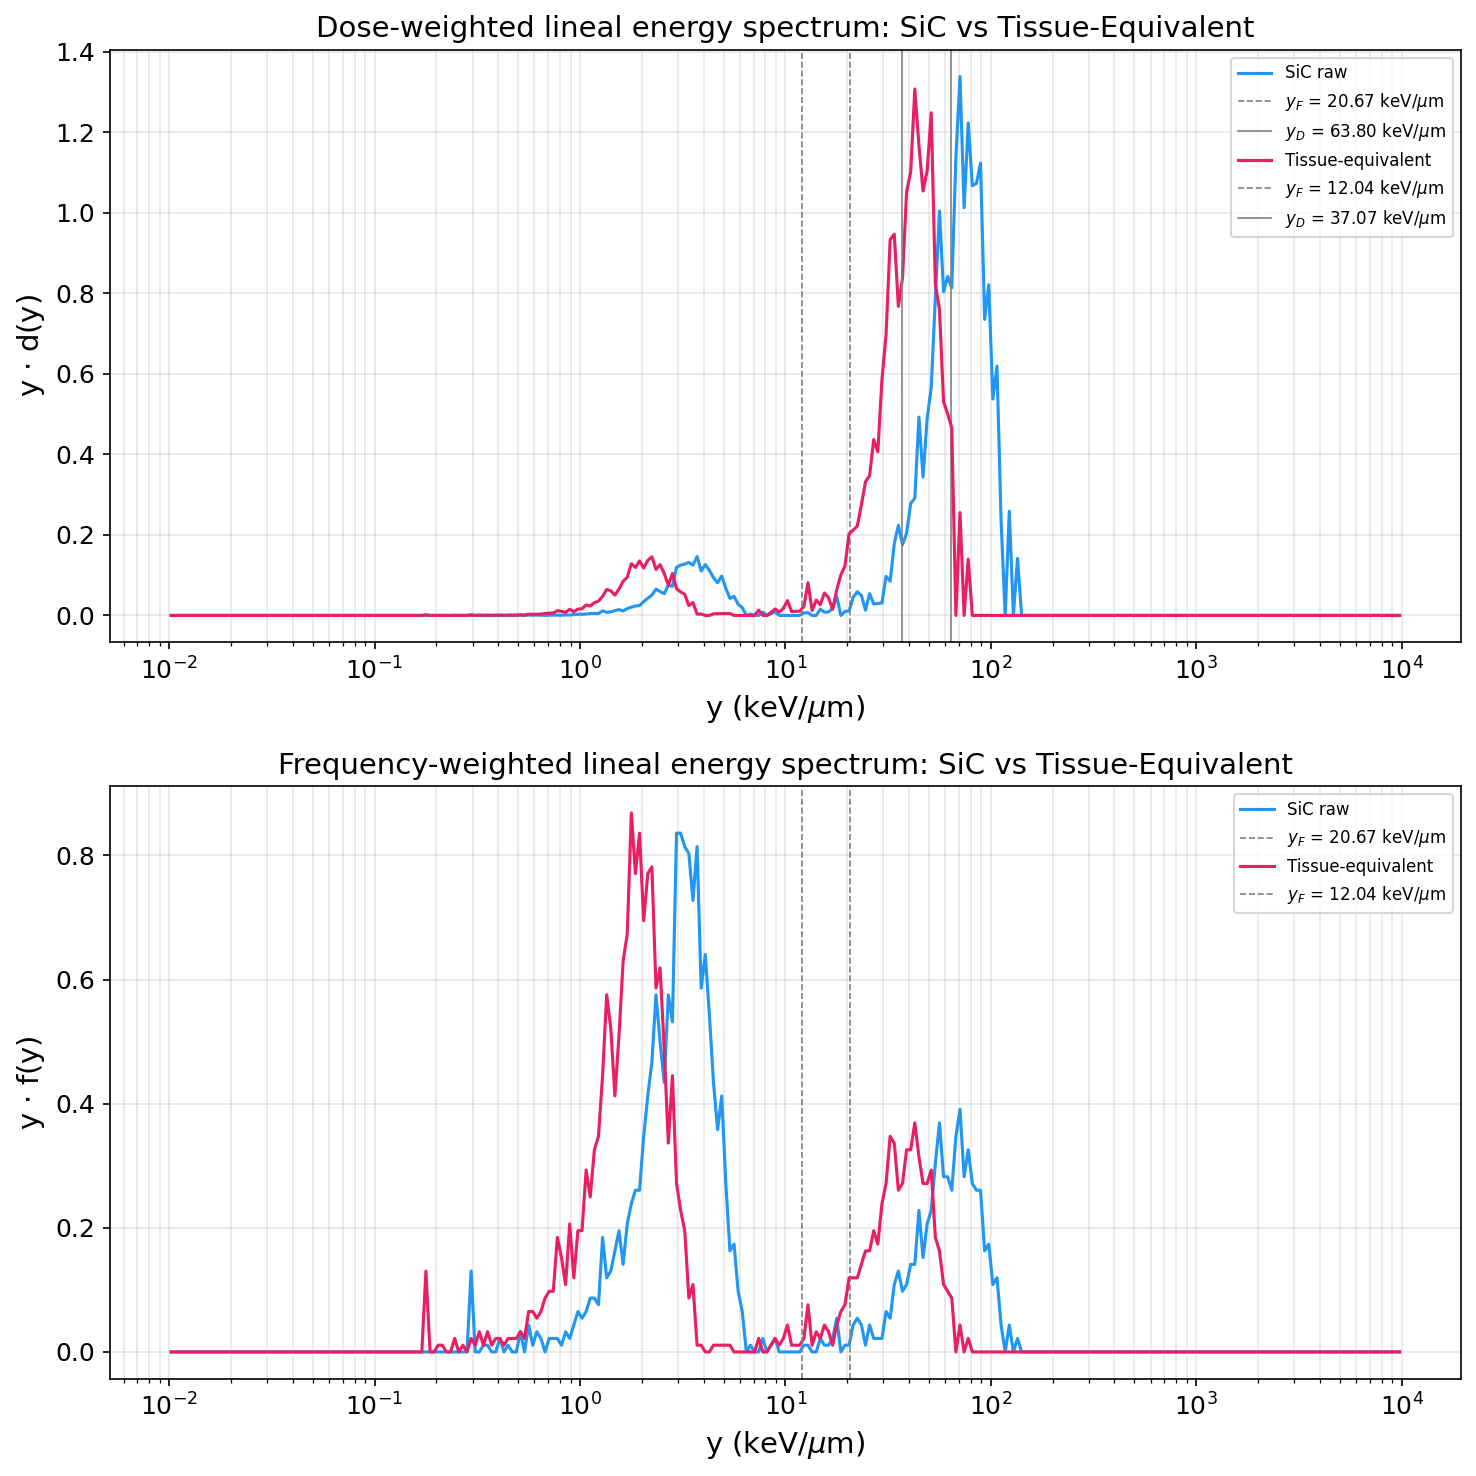

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# --- Top panel: y*d(y) ---
plot_yd_spectrum(
    spec_sic['bin_centers'], spec_sic['d_y'],
    y_F=spec_sic['y_F'], y_D=spec_sic['y_D'],
    ax=ax1, label='SiC raw', color='#2196F3',
)
plot_yd_spectrum(
    spec_tissue['bin_centers'], spec_tissue['d_y'],
    y_F=spec_tissue['y_F'], y_D=spec_tissue['y_D'],
    ax=ax1, label='Tissue-equivalent', color='#E91E63',
)
ax1.set_title('Dose-weighted lineal energy spectrum: SiC vs Tissue-Equivalent')
ax1.grid(True, alpha=0.3, which='both')
# Rebuild legend to avoid duplicate vline labels
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, fontsize=8, loc='upper right')

# --- Bottom panel: y*f(y) ---
plot_yf_spectrum(
    spec_sic['bin_centers'], spec_sic['f_y'],
    y_F=spec_sic['y_F'],
    ax=ax2, label='SiC raw', color='#2196F3',
)
plot_yf_spectrum(
    spec_tissue['bin_centers'], spec_tissue['f_y'],
    y_F=spec_tissue['y_F'],
    ax=ax2, label='Tissue-equivalent', color='#E91E63',
)
ax2.set_title('Frequency-weighted lineal energy spectrum: SiC vs Tissue-Equivalent')
ax2.grid(True, alpha=0.3, which='both')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 7. Summary of Microdosimetric Quantities

Comprehensive comparison of the frequency-mean and dose-mean lineal energies
for both the SiC raw and tissue-equivalent spectra, along with the
tissue-equivalence correction factor kappa.

In [12]:
# Summary table
print("=" * 65)
print("  Microdosimetric Quantities Summary")
print("=" * 65)
print(f"{'Quantity':30s} {'SiC Raw':>12s}  {'Tissue-Eq.':>12s}  {'Unit':>10s}")
print("-" * 65)
print(f"{'y_F (freq. mean)':30s} {spec_sic['y_F']:>12.3f}  "
      f"{spec_tissue['y_F']:>12.3f}  {'keV/um':>10s}")
print(f"{'y_D (dose mean)':30s} {spec_sic['y_D']:>12.3f}  "
      f"{spec_tissue['y_D']:>12.3f}  {'keV/um':>10s}")
print(f"{'y_D / y_F ratio':30s} {spec_sic['y_D']/spec_sic['y_F']:>12.2f}  "
      f"{spec_tissue['y_D']/spec_tissue['y_F']:>12.2f}  {'-':>10s}")
print(f"{'Events':30s} {spec_sic['n_events']:>12d}  "
      f"{spec_tissue['n_events']:>12d}  {'-':>10s}")
print("-" * 65)
print(f"{'Mean kappa':30s} {kappa_table['kappa'].mean():>12.3f}  {'':>12s}  {'-':>10s}")
print(f"{'Kappa range':30s} {kappa_table['kappa'].min():>5.3f} -- "
      f"{kappa_table['kappa'].max():<5.3f}  {'':>12s}  {'-':>10s}")
print("=" * 65)

  Microdosimetric Quantities Summary
Quantity                            SiC Raw    Tissue-Eq.        Unit
-----------------------------------------------------------------
y_F (freq. mean)                     20.666        12.041      keV/um
y_D (dose mean)                      63.796        37.066      keV/um
y_D / y_F ratio                        3.09          3.08           -
Events                                 2000          2000           -
-----------------------------------------------------------------
Mean kappa                            0.580                         -
Kappa range                    0.575 -- 0.587                         -


<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/var/folders/4v/3fndykhd0vq9b0wz8z3g72j80000gn/T/ipykernel_68198/1961187551.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('Lineal energy (keV/$\mu$m)')


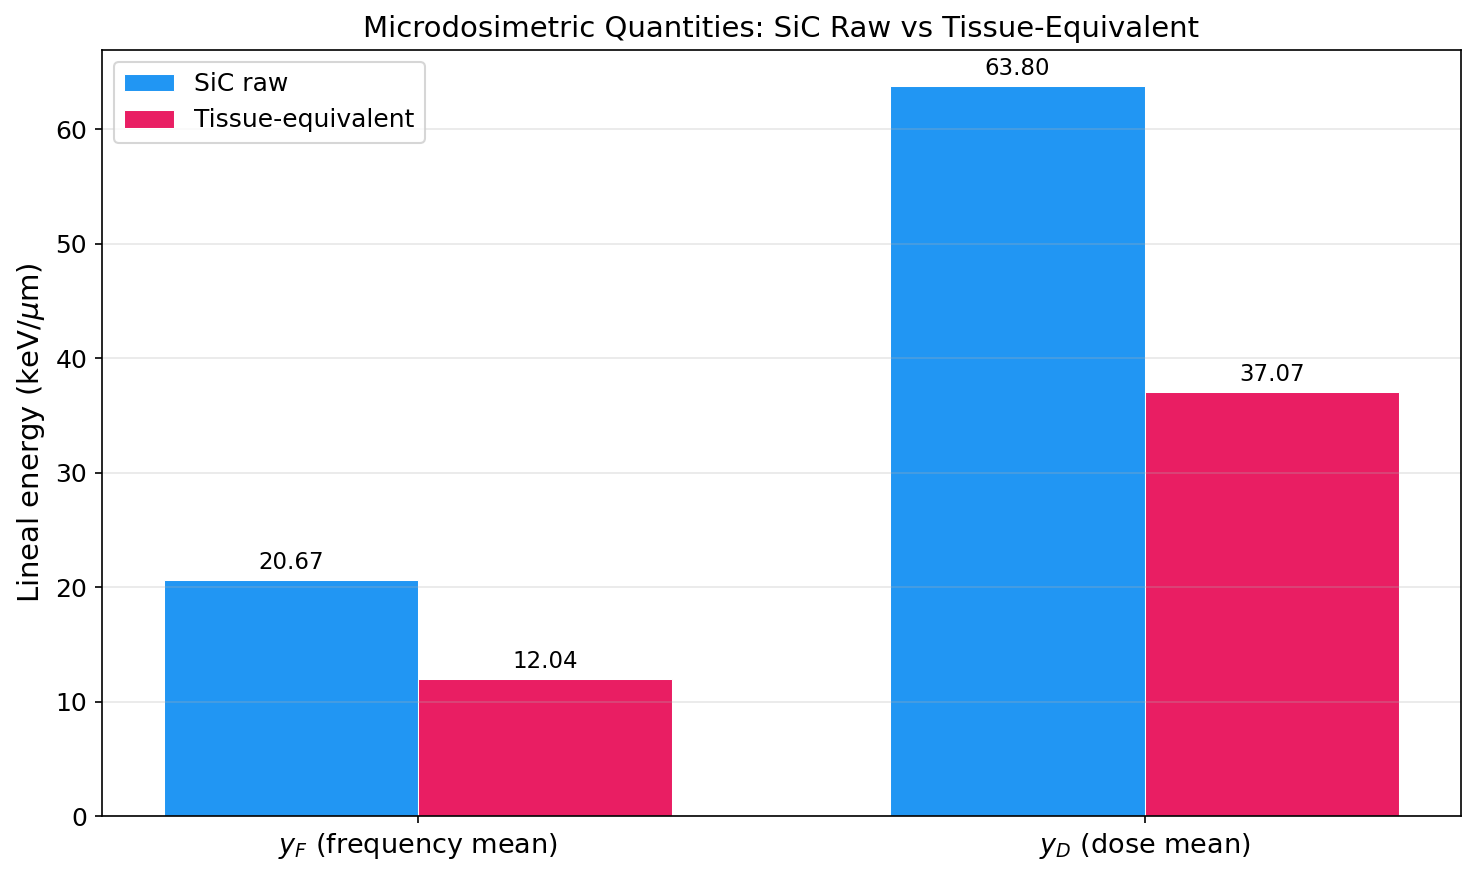

In [13]:
# Figure 4: Bar chart comparing y_F and y_D for SiC vs tissue-equivalent
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.35

bar_sic = [spec_sic['y_F'], spec_sic['y_D']]
bar_tissue = [spec_tissue['y_F'], spec_tissue['y_D']]

bars1 = ax.bar(x - width/2, bar_sic, width, label='SiC raw',
               color='#2196F3', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, bar_tissue, width, label='Tissue-equivalent',
               color='#E91E63', edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(['$y_F$ (frequency mean)', '$y_D$ (dose mean)'], fontsize=13)
ax.set_ylabel('Lineal energy (keV/$\mu$m)')
ax.set_title('Microdosimetric Quantities: SiC Raw vs Tissue-Equivalent')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Conclusions

This notebook demonstrated the complete microdosimetric spectra pipeline for
the 4H-SiC microdosimeter:

**Key findings:**

1. **Lineal energy spectra** were computed from 2000 synthetic MC events using
   ICRU Report 36 conventions. The f(y) normalization validates to within a few
   percent of unity, and Jensen's inequality (y_D >= y_F) is satisfied.

2. **The tissue-equivalence correction** via energy-dependent kappa shifts both
   y_F and y_D to lower values (kappa < 1), reflecting the higher stopping power
   of SiC compared to water. This correction is essential for comparing SiC
   detector measurements with tissue-based dosimetric standards.

3. **The kappa factor** shows energy dependence across the proton energy range
   (0.1--1000 MeV), which is properly captured by the per-event interpolation
   approach rather than a single constant value.

4. **The bimodal mixed-field spectrum** (proton + heavy-ion components) produces
   physically reasonable microdosimetric distributions with clear separation
   between the low-y (proton) and high-y (heavy-ion) contributions.

**Next steps (Phase 24):** Apply this pipeline to realistic Geant4 simulation
data and optimize the SV geometry for microdosimetric performance.